Original image size: (355, 380)

2x2 scaling matrix S =
[[3. 0.]
 [0. 3.]]

3x3 homogeneous scaling matrix S =
[[3. 0. 0.]
 [0. 3. 0.]
 [0. 0. 1.]]

Image centre:
cx = 177.0
cy = 189.5

Option A - centred scale matrix (3x3):
[[   3.    0. -354.]
 [   0.    3. -379.]
 [   0.    0.    1.]]

Hand-checked offsets:
(1-sx)*cx = -354.0
(1-sy)*cy = -379.0

Option B - grown canvas matrix (3x3):
[[  3.   0. 355.]
 [  0.   3. 380.]
 [  0.   0.   1.]]

Canvas A: (355, 380)
Canvas B: (1065, 1140)

Saved enlarged fingerprint:
task1_scaled_fingerprint.jpg


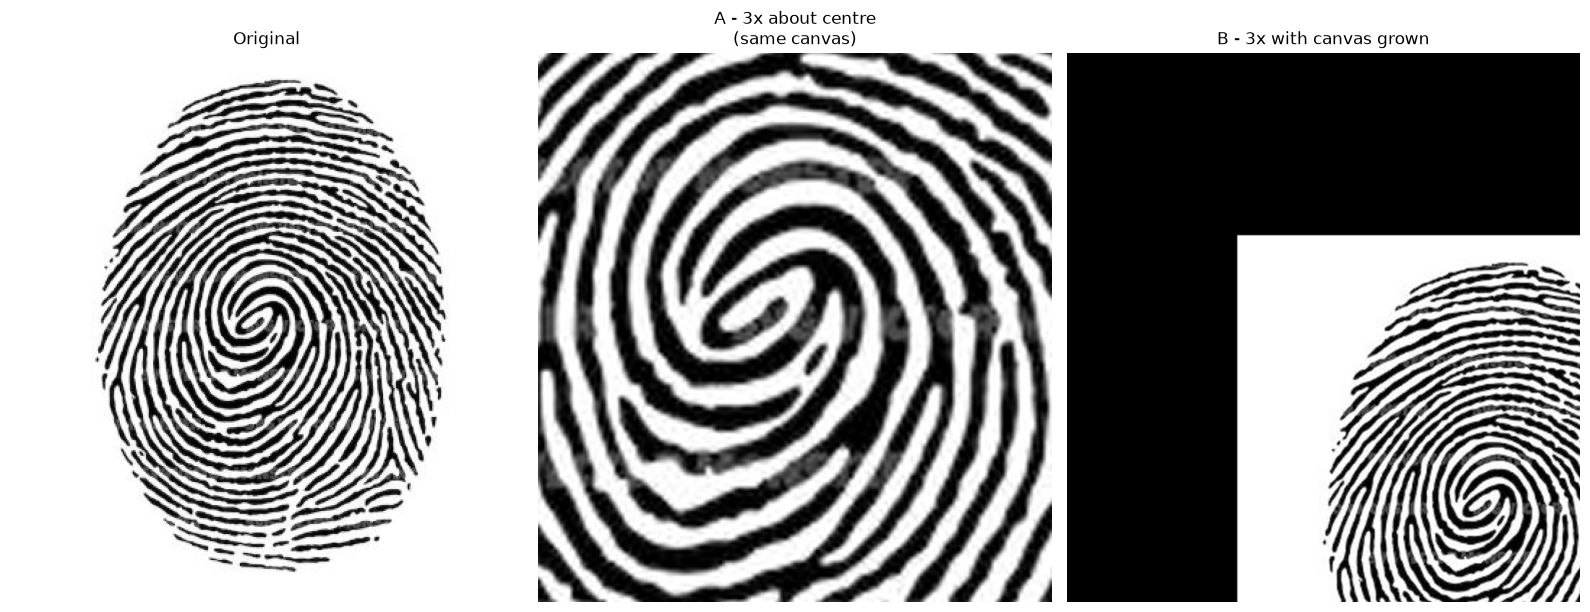

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Input and output
# ---------------------------------------------------------
image_path = "fingerprint.jpg"
output_path = "task1_scaled_fingerprint.jpg"

# ---------------------------------------------------------
# Read image
# ---------------------------------------------------------
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(f"Could not find: {image_path}")

# Convert BGR (OpenCV) to RGB (Matplotlib)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

H_IMG, W_IMG = image.shape[:2]

print("Original image size:", (W_IMG, H_IMG))

# ---------------------------------------------------------
# Raw 2x2 linear scaling matrix
# Typed out by hand
# ---------------------------------------------------------
sx, sy = 3.0, 3.0

S2 = np.array([
    [sx, 0.0],
    [0.0, sy]
], dtype=np.float32)

print("\n2x2 scaling matrix S =")
print(S2)

# ---------------------------------------------------------
# Convert 2x2 matrix into a 3x3 homogeneous matrix
# ---------------------------------------------------------
S3 = np.array([
    [sx, 0.0, 0.0],
    [0.0, sy,  0.0],
    [0.0, 0.0, 1.0]
], dtype=np.float32)

print("\n3x3 homogeneous scaling matrix S =")
print(S3)

# ---------------------------------------------------------
# Original image centre
# ---------------------------------------------------------
cx = (W_IMG - 1) / 2.0
cy = (H_IMG - 1) / 2.0

print("\nImage centre:")
print("cx =", cx)
print("cy =", cy)

# ---------------------------------------------------------
# OPTION A
# Same window size, scale about the centre
#
# x' = sx*x + (1-sx)*cx
# y' = sy*y + (1-sy)*cy
# ---------------------------------------------------------
tx = (1.0 - sx) * cx
ty = (1.0 - sy) * cy

M_zoom = np.array([
    [sx, 0.0, tx],
    [0.0, sy,  ty],
    [0.0, 0.0, 1.0]
], dtype=np.float32)

print("\nOption A - centred scale matrix (3x3):")
print(M_zoom)

print("\nHand-checked offsets:")
print("(1-sx)*cx =", tx)
print("(1-sy)*cy =", ty)

# OpenCV needs a 2x3 affine matrix
M_zoom_2x3 = M_zoom[:2, :]

zoom_same = cv2.warpAffine(
    image,
    M_zoom_2x3,
    (W_IMG, H_IMG),
    flags=cv2.INTER_CUBIC
)

# ---------------------------------------------------------
# OPTION B
# Grow the canvas so that the entire enlarged image fits
# ---------------------------------------------------------
new_W = int(round(W_IMG * sx))
new_H = int(round(H_IMG * sy))

tx_grow = (new_W - W_IMG) / 2.0
ty_grow = (new_H - H_IMG) / 2.0

M_grow = np.array([
    [sx, 0.0, tx_grow],
    [0.0, sy,  ty_grow],
    [0.0, 0.0, 1.0]
], dtype=np.float32)

print("\nOption B - grown canvas matrix (3x3):")
print(M_grow)

size_grow = (new_W, new_H)

zoom_grow = cv2.warpAffine(
    image,
    M_grow[:2, :],
    size_grow,
    flags=cv2.INTER_CUBIC
)

# ---------------------------------------------------------
# Save Option B
# ---------------------------------------------------------
cv2.imwrite(output_path, zoom_grow)

print("\nCanvas A:", (W_IMG, H_IMG))
print("Canvas B:", size_grow)

print("\nSaved enlarged fingerprint:")
print(output_path)

# ---------------------------------------------------------
# Convert results to RGB for Matplotlib
# ---------------------------------------------------------
zoom_same_rgb = cv2.cvtColor(zoom_same, cv2.COLOR_BGR2RGB)
zoom_grow_rgb = cv2.cvtColor(zoom_grow, cv2.COLOR_BGR2RGB)

# ---------------------------------------------------------
# Display all results inside Jupyter Notebook
# ---------------------------------------------------------
plt.figure(figsize=(16, 6))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(zoom_same_rgb)
plt.title("A - 3x about centre\n(same canvas)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(zoom_grow_rgb)
plt.title("B - 3x with canvas grown")
plt.axis("off")

plt.tight_layout()
plt.show()
